# Tutorial 15-2: Balancing Act – "Deep Q-Network (DQN) on CartPole"

**Course:** CSEN 342: Deep Learning  
**Topic:** Deep Reinforcement Learning, DQN, Replay Buffers, and Target Networks

## Objective
In the previous tutorial, we used a Q-Table to solve a small grid world. But what if the state space is continuous (infinite states)? A table is impossible.

**Deep Q-Learning (DQN)** solves this by using a Neural Network to approximate the Q-function:
$$ Q(s, a) \approx Q(s, a; \theta) $$

However, training a Q-Network is unstable. To fix this, DeepMind introduced two key tricks (Mnih et al., 2015):
1.  **Experience Replay:** Store past experiences and sample them randomly to break correlations.
2.  **Target Network:** Use a separate, slow-moving network to calculate the target Q-values.

In this tutorial, we will build a DQN agent to solve the **CartPole** balancing problem.

---

## Part 1: The CartPole Environment

We use OpenAI Gym (now maintained as `gymnasium`). 
**Goal:** Balance a pole on a cart by moving left or right.
**State:** [Cart Position, Cart Velocity, Pole Angle, Pole Angular Velocity].
**Reward:** +1 for every step the pole remains upright.

In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random

# 1. Setup Environment
env = gym.make("CartPole-v1")

state, _ = env.reset()
print(f"State Space: {env.observation_space.shape[0]} (Pos, Vel, Angle, AngVel)")
print(f"Action Space: {env.action_space.n} (0=Left, 1=Right)")
print(f"Sample State: {state}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

State Space: 4 (Pos, Vel, Angle, AngVel)
Action Space: 2 (0=Left, 1=Right)
Sample State: [-0.0326256  -0.01141668 -0.04144653  0.00414472]
Using Device: cuda


---

## Part 2: The Q-Network

The network takes the **State** (size 4) as input and outputs a **Q-Value for each Action** (size 2). 

$$ \text{Input} (4) \to \text{Hidden Layers} \to \text{Output} (2) $$

In [2]:
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

state_size = env.observation_space.shape[0]
action_size = env.action_space.n

# Create two networks: Policy Net (training) and Target Net (stable labels)
policy_net = QNetwork(state_size, action_size).to(device)
target_net = QNetwork(state_size, action_size).to(device)

# Copy weights initially
target_net.load_state_dict(policy_net.state_dict())
target_net.eval() # Target net is never trained, only updated via copy

QNetwork(
  (fc1): Linear(in_features=4, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)

---

## Part 3: Experience Replay

We need a memory buffer to store transitions $(s, a, r, s', done)$. Training on consecutive frames causes overfitting because adjacent frames are highly correlated. Random sampling breaks this correlation.

In [3]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return (
            torch.tensor(np.array(state), dtype=torch.float32).to(device),
            torch.tensor(action, dtype=torch.long).unsqueeze(1).to(device),
            torch.tensor(reward, dtype=torch.float32).unsqueeze(1).to(device),
            torch.tensor(np.array(next_state), dtype=torch.float32).to(device),
            torch.tensor(done, dtype=torch.float32).unsqueeze(1).to(device)
        )

    def __len__(self):
        return len(self.buffer)

memory = ReplayBuffer(10000)

## Part 4: The Training Loop

**The DQN Loss:**
We minimize the MSE between our *predicted* Q-value and the *target* Q-value calculated by the Bellman equation.

$$ \text{Loss} = (Q(s, a) - (r + \gamma \max_{a'} Q_{\text{target}}(s', a')))^2 $$

In [4]:
optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
gamma = 0.99
batch_size = 64
epsilon_start = 1.0
epsilon_end = 0.01
epsilon_decay = 0.995
epsilon = epsilon_start
target_update_freq = 10 # How often to copy weights to target net

def optimize_model():
    if len(memory) < batch_size:
        return
    
    # 1. Sample Batch
    states, actions, rewards, next_states, dones = memory.sample(batch_size)
    
    # 2. Compute Q(s, a) - The value we predicted for the action we took
    # gather(1, actions) selects the Q-value corresponding to the action taken
    current_q = policy_net(states).gather(1, actions)
    
    # 3. Compute Target Q - The Bellman Target
    # We use the TARGET network for stability to estimate the value of the NEXT state
    with torch.no_grad():
        max_next_q = target_net(next_states).max(1)[0].unsqueeze(1)
        target_q = rewards + (gamma * max_next_q * (1 - dones))
        
    # 4. Loss & Backprop
    loss = F.mse_loss(current_q, target_q)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# --- Main Loop ---
num_episodes = 500
episode_rewards = []

print("Starting Training...")
for episode in range(num_episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        # Epsilon-Greedy Action Selection
        if random.random() < epsilon:
            action = env.action_space.sample() # Explore
        else:
            with torch.no_grad():
                state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                action = policy_net(state_tensor).argmax().item() # Exploit
        
        # Take Step
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        # Store Experience
        memory.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        
        # Train Step
        optimize_model()
        
    # End of Episode Updates
    epsilon = max(epsilon_end, epsilon * epsilon_decay)
    episode_rewards.append(total_reward)
    
    if episode % target_update_freq == 0:
        target_net.load_state_dict(policy_net.state_dict())
        
    if episode % 50 == 0:
        print(f"Episode {episode}, Reward: {total_reward}, Epsilon: {epsilon:.2f}")
        
    # Early Stopping if solved
    if np.mean(episode_rewards[-10:]) > 195:
        print(f"Solved at episode {episode}!")
        break

print("Training Complete.")

Starting Training...
Episode 0, Reward: 40.0, Epsilon: 0.99
Episode 50, Reward: 17.0, Epsilon: 0.77
Episode 100, Reward: 32.0, Epsilon: 0.60
Episode 150, Reward: 180.0, Epsilon: 0.47
Episode 200, Reward: 201.0, Epsilon: 0.37
Episode 250, Reward: 119.0, Epsilon: 0.28
Solved at episode 296!
Training Complete.


## Part 5: Visualization

Let's plot the learning curve. We expect to see the reward start low (random actions) and climb towards 200 (max score).

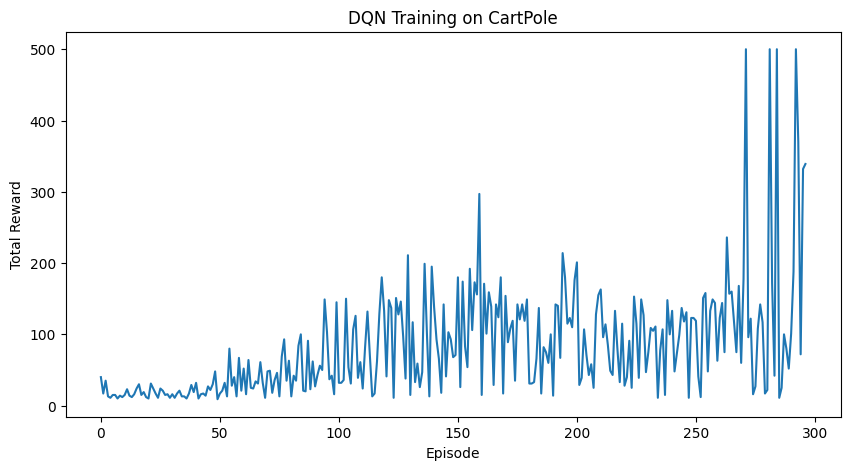

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards)
plt.title("DQN Training on CartPole")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

The trend is better observed in a moving average plot.

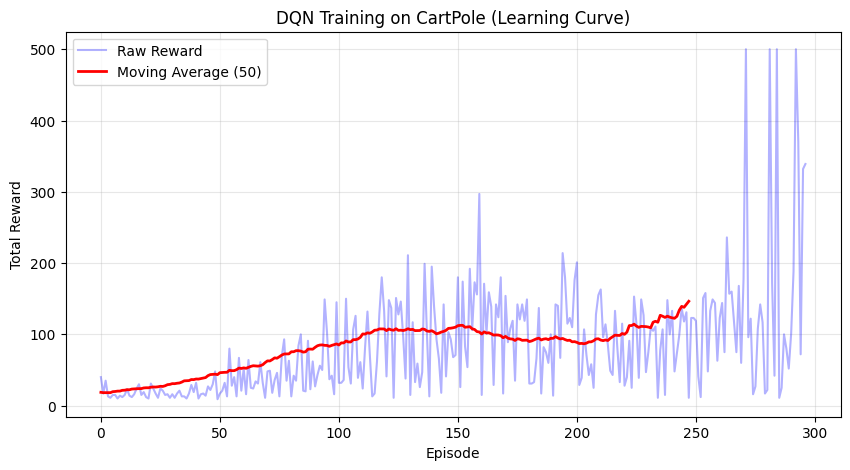

In [6]:
import numpy as np

# Helper function to calculate moving average
def get_moving_average(data, window=50):
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window)/window, mode='valid')

# Plotting the results
plt.figure(figsize=(10, 5))

# Plot raw rewards with transparency
plt.plot(episode_rewards, alpha=0.3, color='blue', label="Raw Reward")

# Calculate and plot moving average (window of 50 episodes)
moving_avg = get_moving_average(episode_rewards, window=50)
plt.plot(range(len(moving_avg)), moving_avg, color='red', linewidth=2, label="Moving Average (50)")

plt.title("DQN Training on CartPole (Learning Curve)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

To visualize the "brain" we just trained, we can now render the environment and capture the frames to create an animation.

In [10]:
import os
# Create a dummy runtime directory to satisfy the XDG requirement
os.environ['XDG_RUNTIME_DIR'] = '/tmp/runtime-root'
if not os.path.exists(os.environ['XDG_RUNTIME_DIR']):
    os.makedirs(os.environ['XDG_RUNTIME_DIR'], exist_ok=True)

# Use 'agg' backend for matplotlib to avoid GUI dependency
import matplotlib
matplotlib.use('Agg')

import matplotlib.animation as animation
from IPython.display import HTML

def visualize_simulation(env_name, policy_net, device, max_steps=500):
    # Re-create environment for rendering
    test_env = gym.make(env_name, render_mode="rgb_array")
    state, _ = test_env.reset()
    frames = []
    done = False
    steps = 0
    
    print("Simulating trained policy...")
    while not done and steps < max_steps:
        # Capture frame
        frames.append(test_env.render())
        
        # Select best action (no epsilon exploration)
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            action = policy_net(state_t).argmax().item()
            
        state, reward, terminated, truncated, _ = test_env.step(action)
        done = terminated or truncated
        steps += 1
    
    test_env.close()
    print(f"Simulation finished after {steps} steps.")
    
    # Create Animation
    fig = plt.figure(figsize=(6, 4))
    plt.axis('off')
    patch = plt.imshow(frames[0])

    def animate(i):
        patch.set_data(frames[i])

    anim = animation.FuncAnimation(fig, animate, frames=len(frames), interval=50)
    plt.close() # Prevent extra plot showing
    return HTML(anim.to_jshtml())

# Run the visualization
visualize_simulation("CartPole-v1", policy_net, device)

Simulating trained policy...
Simulation finished after 320 steps.


### Conclusion

You have built a DQN agent! 

**Why did we need the Target Network?**
Imagine trying to hit a target that moves every time you shoot. If we used the same network for both the prediction and the target value, the "target" would shift constantly, leading to oscillations.

**Why did we need the Replay Buffer?**
In RL, data is sequential. If the cart is moving right, the next 10 frames will all be "moving right". A neural network trained on such a batch would overfit to "always move left to compensate". The buffer shuffles this data, making it look like Independent Identically Distributed (I.I.D.) data, which neural networks love.